In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate date range (1 year)
dates = pd.date_range(start="2025-01-01", end="2025-12-31")

# Define 5 zones
zones = ["Z1", "Z2", "Z3", "Z4", "Z5"]

# Create empty list
data = []

# Loop through dates and zones
for date in dates:
    day = date.dayofyear

    # Seasonal temperature (realistic variation using sine wave)
    base_temp = 25 + 10 * np.sin(2 * np.pi * day / 365)

    for zone in zones:
        # Add randomness to temperature
        temp = base_temp + np.random.normal(0, 2)

        # Humidity (inverse relation with temperature)
        humidity = 70 - (temp - 25) + np.random.normal(0, 5)
        humidity = np.clip(humidity, 30, 90)

        # Special events (10% probability)
        event = np.random.choice([0, 1], p=[0.9, 0.1])

        # Zone-based consumption variation
        zone_factor = int(zone[-1]) * 20

        # Energy consumption formula (realistic)
        energy = (
            200
            + temp * 8               # higher temp → more AC usage
            + humidity * 2          # humidity effect
            + event * 100           # spike during events
            + zone_factor           # zone variation
            + np.random.normal(0, 20)  # random noise
        )

        # Append row
        data.append([
            date.strftime("%Y-%m-%d"),
            zone,
            round(temp, 2),
            round(humidity, 2),
            event,
            round(energy, 2)
        ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Date",
    "ZoneID",
    "AvgTemperature",
    "Humidity",
    "SpecialEvent",
    "EnergyConsumption"
])

# Save dataset
df.to_csv("city_energy_dataset.csv", index=False)

# Display sample
print(df.head())

# Total rows check
print("Total Rows:", len(df))

         Date ZoneID  AvgTemperature  Humidity  SpecialEvent  \
0  2025-01-01     Z1           26.17     68.14             0   
1  2025-01-01     Z2           25.81     70.59             0   
2  2025-01-01     Z3           24.23     73.48             0   
3  2025-01-01     Z4           23.32     58.61             0   
4  2025-01-01     Z5           23.15     73.42             0   

   EnergyConsumption  
0             543.37  
1             607.86  
2             589.40  
3             602.83  
4             617.95  
Total Rows: 1825


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("city_energy_dataset.csv")

# Check data
print(df.head())
print(df.info())

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print(df.isnull().sum())

# Drop duplicates (if any)
df = df.drop_duplicates()

         Date ZoneID  AvgTemperature  Humidity  SpecialEvent  \
0  2025-01-01     Z1           26.17     68.14             0   
1  2025-01-01     Z2           25.81     70.59             0   
2  2025-01-01     Z3           24.23     73.48             0   
3  2025-01-01     Z4           23.32     58.61             0   
4  2025-01-01     Z5           23.15     73.42             0   

   EnergyConsumption  
0             543.37  
1             607.86  
2             589.40  
3             602.83  
4             617.95  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1825 non-null   object 
 1   ZoneID             1825 non-null   object 
 2   AvgTemperature     1825 non-null   float64
 3   Humidity           1825 non-null   float64
 4   SpecialEvent       1825 non-null   int64  
 5   EnergyConsumption  1825 non-nu

In [7]:
       #Monthly Average Consumption

df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['EnergyConsumption'].mean()
print(monthly_avg)


       #Zone-wise Average

zone_avg = df.groupby('ZoneID')['EnergyConsumption'].mean()
print(zone_avg)

Month
1     623.866129
2     652.911786
3     663.233097
4     662.440867
5     649.846645
6     627.187867
7     595.304774
8     570.293484
9     556.318733
10    554.296000
11    566.134600
12    591.588452
Name: EnergyConsumption, dtype: float64
ZoneID
Z1    571.296521
Z2    587.725507
Z3    610.357342
Z4    628.672274
Z5    647.774082
Name: EnergyConsumption, dtype: float64


In [6]:
        # Correlation

correlation = df.corr(numeric_only=True)
print(correlation)

                   AvgTemperature  Humidity  SpecialEvent  EnergyConsumption  \
AvgTemperature           1.000000 -0.817644     -0.082824           0.672017   
Humidity                -0.817644  1.000000      0.062168          -0.466962   
SpecialEvent            -0.082824  0.062168      1.000000           0.418646   
EnergyConsumption        0.672017 -0.466962      0.418646           1.000000   
Month                   -0.754141  0.606044      0.070231          -0.515169   

                      Month  
AvgTemperature    -0.754141  
Humidity           0.606044  
SpecialEvent       0.070231  
EnergyConsumption -0.515169  
Month              1.000000  


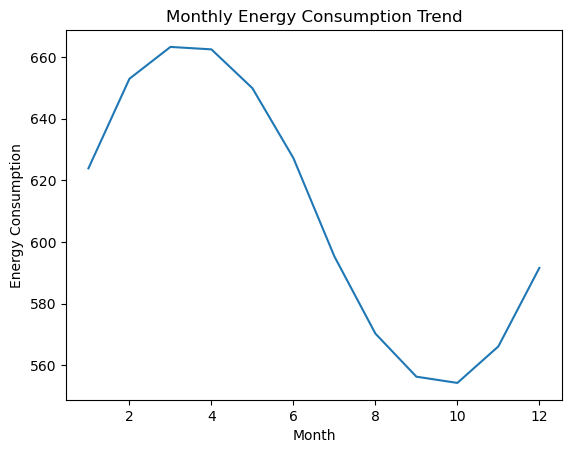

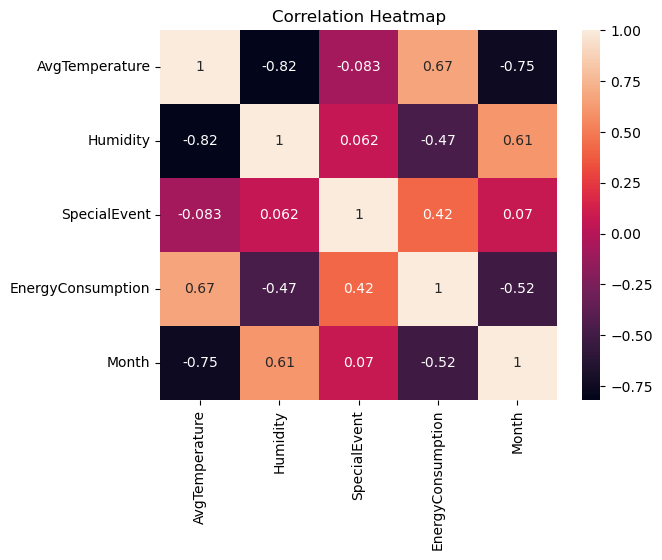

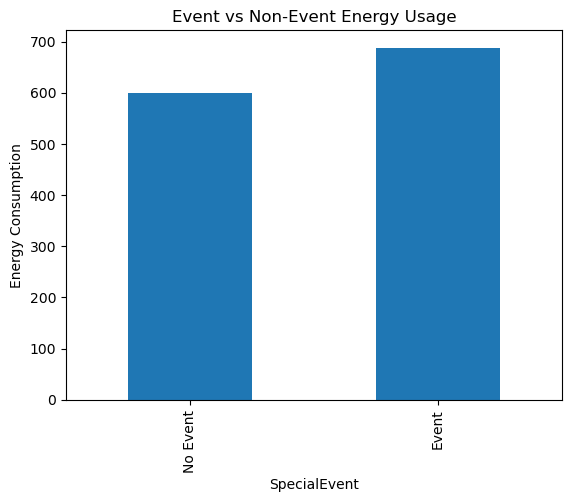

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly average
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['EnergyConsumption'].mean()

# Correlation
correlation = df.corr(numeric_only=True)

# Event vs Non-event
event_avg = df.groupby('SpecialEvent')['EnergyConsumption'].mean()

# --------- PLOTS ---------

# 1. Line Chart
plt.figure()
monthly_avg.plot(kind='line')
plt.title("Monthly Energy Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Energy Consumption")
plt.show()

# 2. Heatmap
plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 3. Bar Chart
plt.figure()
event_avg.plot(kind='bar')
plt.title("Event vs Non-Event Energy Usage")
plt.xticks([0,1], ['No Event','Event'])
plt.ylabel("Energy Consumption")
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("city_energy_dataset.csv")
print(df.head())

         Date ZoneID  AvgTemperature  Humidity  SpecialEvent  \
0  2025-01-01     Z1           26.17     68.14             0   
1  2025-01-01     Z2           25.81     70.59             0   
2  2025-01-01     Z3           24.23     73.48             0   
3  2025-01-01     Z4           23.32     58.61             0   
4  2025-01-01     Z5           23.15     73.42             0   

   EnergyConsumption  
0             543.37  
1             607.86  
2             589.40  
3             602.83  
4             617.95  


In [4]:
                #  Model Training

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Features (input)
X = df[['AvgTemperature', 'Humidity', 'SpecialEvent']]

# Target (output)
y = df['EnergyConsumption']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)

print("Model trained successfully ✅")
print("Mean Absolute Error (MAE):", mae)

Model trained successfully ✅
Mean Absolute Error (MAE): 28.335261991289826


In [5]:
import pandas as pd
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

zone = input("Enter Zone (Z1-Z5): ")
temp = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
event = int(input("Event (0/1): "))

# Create proper input with column names
input_data = pd.DataFrame({
    'AvgTemperature': [temp],
    'Humidity': [humidity],
    'SpecialEvent': [event]
})

# Predict
prediction = model.predict(input_data)

print(f"\nPredicted Energy for {zone}: {prediction[0]:.2f} kWh")

Enter Zone (Z1-Z5):  Z1
Enter Temperature:  30
Enter Humidity:  60
Event (0/1):  1



Predicted Energy for Z1: 718.11 kWh


In [6]:
   ###  Safe Input with Error Handling

try:
    zone = input("Enter Zone (Z1-Z5): ")

    if zone not in ['Z1','Z2','Z3','Z4','Z5']:
        raise ValueError("Invalid Zone! Use Z1–Z5")

    temp = float(input("Enter Temperature: "))
    humidity = float(input("Enter Humidity: "))
    event = int(input("Event (0/1): "))

    if event not in [0,1]:
        raise ValueError("Event must be 0 or 1")

    prediction = model.predict([[temp, humidity, event]])

    print(f"\nPredicted Energy for {zone}: {prediction[0]:.2f} kWh")

except Exception as e:
    print("Error:", e)

Enter Zone (Z1-Z5):  Z2
Enter Temperature:  30
Enter Humidity:  60
Event (0/1):  1



Predicted Energy for Z2: 718.11 kWh
